# 04 — Failure Case Analysis

Load the KITTI-C results CSV and produce:
- Per-corruption summary tables
- Severity curves
- Worst / median / best image galleries

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'configs' / 'dataset_paths.yaml').exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate project root from the current working directory')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

from src.analysis.failure_slices import get_worst_n, get_best_n, get_median_n
from src.analysis.report_tables import corruption_summary_table, severity_curve, per_corruption_severity_pivot

RESULTS_CSV = PROJECT_ROOT / 'outputs' / 'metrics' / 'kittic_results.csv'
GALLERY_DIR = PROJECT_ROOT / 'outputs' / 'galleries' / 'kitti_c'

df = pd.read_csv(RESULTS_CSV, dtype={'frame_id': str})
print(f'Loaded {len(df)} results')

if len(df) == 0:
    raise RuntimeError(
        f'No rows found in {RESULTS_CSV}. Run notebook 02, then notebook 03, '
        'before doing failure-case analysis.'
    )

df.head()


Loaded 59332 results


,image_path,gt_path,pred_path,dataset,corruption_type,severity,sequence,frame_id,model_name,abs_rel,sq_rel,rmse,rmse_log,delta1,delta2,delta3,n_valid
0,/home/kaiyul3/cs543/data/raw/kitti_c/kitti_c/b...,/home/kaiyul3/cs543/data/raw/kitti_c/val/2011_...,/home/kaiyul3/cs543/outputs/predictions/kitti_...,kitti_c,brightness,1,2011_09_26_drive_0002_sync,0000000006,dpt_hybrid_384,0.278434,1.523782,5.730038,1.613404,0.512982,0.834093,0.889498,25882
1,/home/kaiyul3/cs543/data/raw/kitti_c/kitti_c/b...,/home/kaiyul3/cs543/data/raw/kitti_c/val/2011_...,/home/kaiyul3/cs543/outputs/predictions/kitti_...,kitti_c,brightness,1,2011_09_26_drive_0002_sync,0000000009,dpt_hybrid_384,0.293952,1.604439,5.762776,1.699609,0.442979,0.835193,0.893248,26613
2,/home/kaiyul3/cs543/data/raw/kitti_c/kitti_c/b...,/home/kaiyul3/cs543/data/raw/kitti_c/val/2011_...,/home/kaiyul3/cs543/outputs/predictions/kitti_...,kitti_c,brightness,1,2011_09_26_drive_0002_sync,0000000012,dpt_hybrid_384,0.340985,2.165371,6.625548,1.667024,0.452380,0.721316,0.866979,27289
3,/home/kaiyul3/cs543/data/raw/kitti_c/kitti_c/b...,/home/kaiyul3/cs543/data/raw/kitti_c/val/2011_...,/home/kaiyul3/cs543/outputs/predictions/kitti_...,kitti_c,brightness,1,2011_09_26_drive_0002_sync,0000000015,dpt_hybrid_384,0.336149,1.899179,6.029233,1.873050,0.441490,0.775655,0.858608,28474
4,/home/kaiyul3/cs543/data/raw/kitti_c/kitti_c/b...,/home/kaiyul3/cs543/data/raw/kitti_c/val/2011_...,/home/kaiyul3/cs543/outputs/predictions/kitti_...,kitti_c,brightness,1,2011_09_26_drive_0002_sync,0000000018,dpt_hybrid_384,0.368317,2.259750,6.459181,2.088285,0.408362,0.726071,0.849040,28438


In [3]:
print('=== Corruption summary (mean abs_rel) ===')
corruption_summary_table(df)[['abs_rel', 'rmse', 'delta1']]

=== Corruption summary (mean abs_rel) ===


,abs_rel,rmse,delta1
corruption_type,,,
clean,0.300600,6.509561,0.511118
brightness,0.301877,6.520552,0.507209
elastic_transform,0.304479,6.543849,0.502446
contrast,0.307479,6.594641,0.502485
pixelate,0.309759,6.652829,0.492550
fog,0.311602,6.693770,0.499945
color_quant,0.318598,6.800846,0.486455
shot_noise,0.322812,7.027143,0.487252
motion_blur,0.324435,6.963136,0.482125


In [4]:
print('=== Per-corruption severity pivot (abs_rel) ===')
per_corruption_severity_pivot(df, metric='abs_rel')

=== Per-corruption severity pivot (abs_rel) ===


severity,0,1,2,3,4,5
corruption_type,,,,,,
brightness,NaN,0.300165,0.299963,0.300933,0.302668,0.305658
clean,0.3006,NaN,NaN,NaN,NaN,NaN
color_quant,NaN,0.301748,0.305903,0.309705,0.324564,0.351068
contrast,NaN,0.303441,0.303882,0.305484,0.309914,0.314675
dark,NaN,0.308248,0.313075,0.323489,0.339492,0.360327
defocus_blur,NaN,0.313364,0.323038,0.347840,0.373649,0.397421
elastic_transform,NaN,0.302671,0.303082,0.303612,0.305964,0.307065
fog,NaN,0.306783,0.308076,0.309827,0.311677,0.321649
frost,NaN,0.317074,0.339234,0.351968,0.355512,0.365106


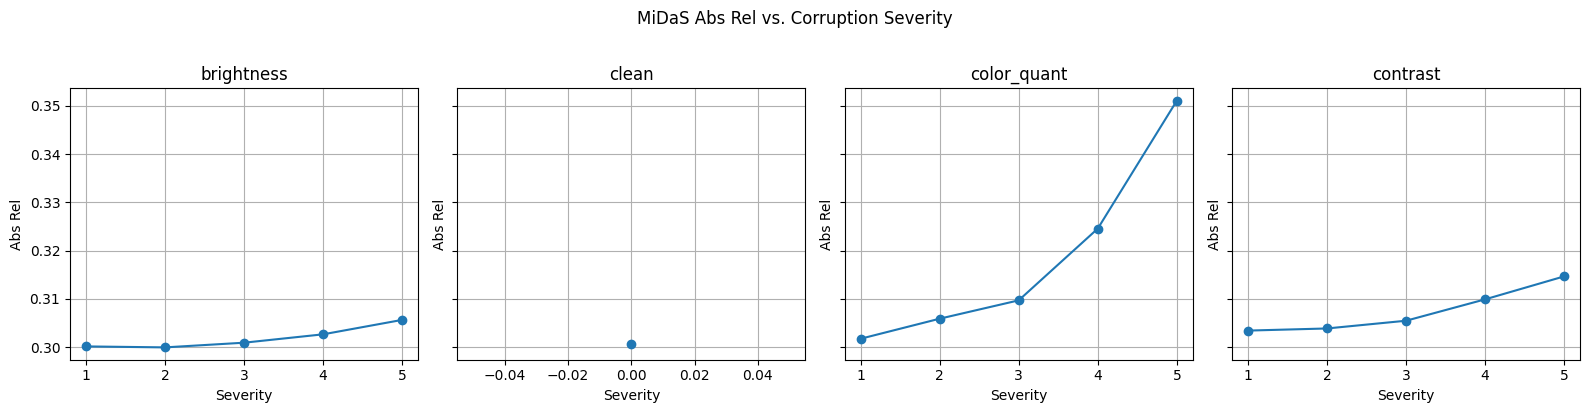

In [5]:
# Severity curves for all corruption types
corruptions = sorted(df['corruption_type'].unique())

fig, axes = plt.subplots(1, min(len(corruptions), 4), figsize=(16, 4), sharey=True)
if len(corruptions) == 1:
    axes = [axes]

for ax, ct in zip(axes, corruptions[:4]):
    curve = severity_curve(df, ct)
    ax.plot(curve['severity'], curve['abs_rel'], marker='o')
    ax.set_title(ct)
    ax.set_xlabel('Severity')
    ax.set_ylabel('Abs Rel')
    ax.grid(True)

plt.suptitle('MiDaS Abs Rel vs. Corruption Severity', y=1.02)
plt.tight_layout()
plt.show()

Worst corruption type: snow


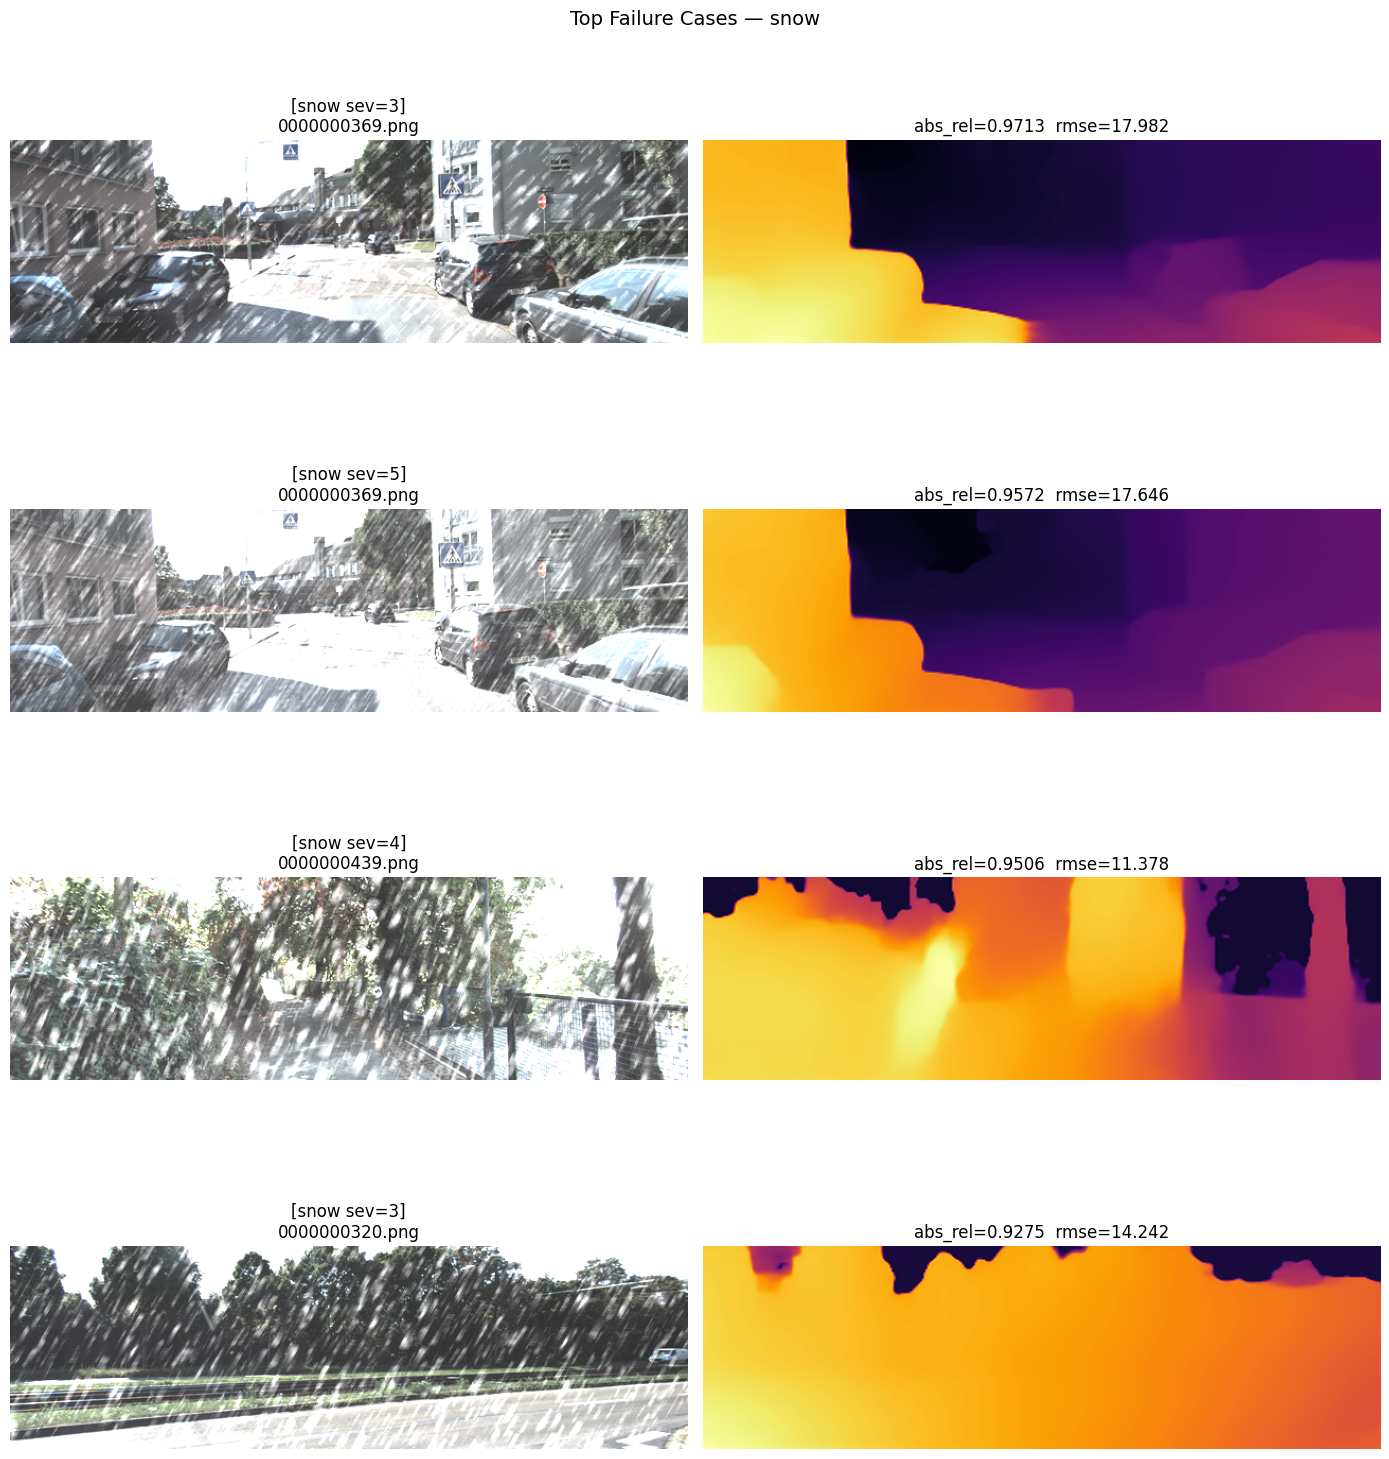

In [6]:
# Gallery: worst 4 images for the highest-error corruption type
worst_corruption = corruption_summary_table(df)['abs_rel'].idxmax()
print(f'Worst corruption type: {worst_corruption}')

worst_rows = get_worst_n(df, metric='abs_rel', corruption_type=worst_corruption, n=4)

fig, axes = plt.subplots(len(worst_rows), 2, figsize=(14, 4 * len(worst_rows)))
if len(worst_rows) == 1:
    axes = [axes]

for i, (_, row) in enumerate(worst_rows.iterrows()):
    try:
        img = cv2.cvtColor(cv2.imread(row['image_path']), cv2.COLOR_BGR2RGB)
        depth = np.load(row['pred_path'])

        axes[i][0].imshow(img)
        axes[i][0].set_title(f"[{row['corruption_type']} sev={row['severity']}]\n{Path(row['image_path']).name}")
        axes[i][0].axis('off')

        axes[i][1].imshow(depth, cmap='inferno')
        axes[i][1].set_title(f"abs_rel={row['abs_rel']:.4f}  rmse={row['rmse']:.3f}")
        axes[i][1].axis('off')
    except Exception as e:
        print(f'Could not show row {i}: {e}')

plt.suptitle(f'Top Failure Cases — {worst_corruption}', fontsize=14)
plt.tight_layout()
plt.show()